<a href="https://colab.research.google.com/github/llllllllie/TIL/blob/main/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 목차
1.  **분석 환경 설정**
2.  **유기동물 보호현황 데이터 불러오기**
3.  **데이터 전처리: 컬럼명 정리, - 값 처리, 숫자 변환**
4.  **주요 보호 지표 계산**
    *   **주요 지표별 순위 확인 : 상위 5개구 확인**
5.  **분석 대상 데이터 필터링: 소계 제외**
6.  **자치구별 입양률 비교**
7.  **자치구별 보호 지표 종합 비교: 4개 지표 막대그래프**
8.  **자치구별 보호 지표 히트맵 분석**
9.  **입양률과 폐사·안락사율의 관계 분석**
10. **보호 지표 분포 및 이상치 분석: 박스플롯**
11. **자치구별 인구 데이터 불러오기**
    *   **인구 데이터 전처리**
12. **유기동물 데이터와 인구 데이터 병합**
13. **인구 표준화 지표 계산: 인구 1만명당 발생률 계산**
14. **최종 분석 데이터 저장**
15. **인구 1만명당 유기동물 발생률 비교: 막대그래프**
16. **인구수와 유기동물 발생 건수의 관계 분석: 인구수 vs 총 발생 건수 산점도**
17. **주요 위험 지역 도출: 유기동물 발생률 상위/하위 지역 확인**
    *   **주요 위험 지역 도출: 폐사·안락사율 상위/하위 지역 확인**
18. **입양률과 폐사·안락사율의 상관관계 분석: 산점도**

<h1 id="section-1">1. 분석 환경 설정</h1>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#텍스트 레이블 분리
!pip install adjustText

# 한글 폰트 설정 (코랩에서 필수)
!pip install koreanize-matplotlib
import koreanize_matplotlib

In [ ]:
# 1. 나눔 폰트 설치 (코랩용)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. 런타임 다시 시작 (중요!)
# 이 코드를 실행한 후, 상단 메뉴에서 [런타임] -> [세션 다시 시작]을 눌러주세요.
# 세션이 다시 시작되면 아래 3번 코드를 실행합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

<h1 id="section-2">2. 유기동물 보호현황 데이터 불러오기</h1>

In [ ]:
df = pd.read_csv('/content/유기동물보호현황_20260601041058.csv')
display(df.info())
display(df) # 원본데이터에 결측치 존재 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   자치구별(1)  29 non-null     object
 1   자치구별(2)  29 non-null     object
 2   2025     29 non-null     object
 3   2025.1   29 non-null     object
 4   2025.2   29 non-null     object
 5   2025.3   29 non-null     object
 6   2025.4   29 non-null     object
 7   2025.5   29 non-null     object
 8   2025.6   29 non-null     object
 9   2025.7   29 non-null     object
 10  2025.8   29 non-null     object
 11  2025.9   29 non-null     object
 12  2025.10  29 non-null     object
 13  2025.11  29 non-null     object
 14  2025.12  29 non-null     object
 15  2025.13  29 non-null     object
 16  2025.14  29 non-null     object
 17  2025.15  29 non-null     object
dtypes: object(18)
memory usage: 4.2+ KB


None

,자치구별(1),자치구별(2),2025,2025.1,2025.2,2025.3,2025.4,2025.5,2025.6,2025.7,2025.8,2025.9,2025.10,2025.11,2025.12,2025.13,2025.14,2025.15
0,자치구별(1),자치구별(2),합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계,합계
1,자치구별(1),자치구별(2),소계,개,개,개,개,개,고양이,고양이,고양이,고양이,고양이,기타,기타,기타,기타,기타
2,자치구별(1),자치구별(2),소계,소계,인도(주인),입양 기증,폐사안락사,계류 방사,소계,인도(주인),입양 기증,폐사안락사,계류 방사,소계,인도(주인),입양 기증,폐사안락사,계류 방사
3,합계,소계,4278,1980,818,693,417,52,2055,51,794,1111,99,243,12,126,90,15
4,합계,종로구,153,48,13,11,24,-,101,1,19,78,3,4,-,-,4,-
5,합계,중구,51,23,11,7,5,-,20,2,7,9,2,8,1,3,2,2
6,합계,용산구,223,78,50,17,11,-,135,2,68,62,3,10,-,8,2,-
7,합계,성동구,145,45,23,16,6,-,88,5,52,29,2,12,-,9,3,-
8,합계,광진구,115,46,16,21,9,-,68,-,16,52,-,1,-,-,1,-
9,합계,동대문구,373,80,27,39,3,11,274,2,185,34,53,19,-,6,1,12


<h1 id="section-3">3. 데이터 전처리: 컬럼명 정리, - 값 처리, 숫자 변환</h1>

In [ ]:

# 1. 데이터프레임의 열 이름 정리 (header cleanup)
# 새로운 열 이름을 저장할 리스트 초기화
new_column_names = []

# 첫 두 열은 '구분'과 '자치구명'으로 명시적으로 설정
new_column_names.append('구분')
new_column_names.append('자치구명')

# 나머지 열 이름은 기존 df의 1번째(동물 유형)와 2번째(세부 카테고리) 행을 조합하여 생성
# 기존 df의 컬럼 인덱스 2부터 시작
for i in range(2, len(df.columns)):
    animal_type = df.iloc[1, i] # 예: '소계', '개', '고양이', '기타'
    detail_category = df.iloc[2, i] # 예: '소계', '인도(주인)', '입양 기증', '폐사안락사', '계류 방사'

    if animal_type == '소계' and detail_category == '소계':
        col_name = '총_합계'
    elif animal_type == detail_category:
        col_name = f'{animal_type}_{detail_category}'
    else:
        col_name = f'{animal_type}_{detail_category}'
    new_column_names.append(col_name.replace(' ', '')) # 공백 제거하여 열 이름 정리

# 새로운 열 이름 적용
df.columns = new_column_names

# 헤더로 사용된 상위 3개 행 (인덱스 0, 1, 2) 제거 및 인덱스 재설정
df = df.iloc[3:].reset_index(drop=True)

# 2. 전체 데이터에서 '-' 문자를 찾아 0으로 교체 (사용자 요청)
df = df.replace('-', 0)

# 3. 숫자 타입으로 강제 변환
# '구분' 및 '자치구명'을 제외한 모든 열을 숫자형으로 변환
columns_to_convert = [col for col in df.columns if col not in ['구분', '자치구명']]

for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col])

# 변환 결과를 확인하기 위해 df의 정보 출력
display(df.info())
display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   구분          26 non-null     object
 1   자치구명        26 non-null     object
 2   총_합계        26 non-null     int64 
 3   개_소계        26 non-null     int64 
 4   개_인도(주인)    26 non-null     int64 
 5   개_입양기증      26 non-null     int64 
 6   개_폐사안락사     26 non-null     int64 
 7   개_계류방사      26 non-null     int64 
 8   고양이_소계      26 non-null     int64 
 9   고양이_인도(주인)  26 non-null     int64 
 10  고양이_입양기증    26 non-null     int64 
 11  고양이_폐사안락사   26 non-null     int64 
 12  고양이_계류방사    26 non-null     int64 
 13  기타_소계       26 non-null     int64 
 14  기타_인도(주인)   26 non-null     int64 
 15  기타_입양기증     26 non-null     int64 
 16  기타_폐사안락사    26 non-null     int64 
 17  기타_계류방사     26 non-null     int64 
dtypes: int64(16), object(2)
memory usage: 3.8+ KB


None

,구분,자치구명,총_합계,개_소계,개_인도(주인),개_입양기증,개_폐사안락사,개_계류방사,고양이_소계,고양이_인도(주인),고양이_입양기증,고양이_폐사안락사,고양이_계류방사,기타_소계,기타_인도(주인),기타_입양기증,기타_폐사안락사,기타_계류방사
0,합계,소계,4278,1980,818,693,417,52,2055,51,794,1111,99,243,12,126,90,15
1,합계,종로구,153,48,13,11,24,0,101,1,19,78,3,4,0,0,4,0
2,합계,중구,51,23,11,7,5,0,20,2,7,9,2,8,1,3,2,2
3,합계,용산구,223,78,50,17,11,0,135,2,68,62,3,10,0,8,2,0
4,합계,성동구,145,45,23,16,6,0,88,5,52,29,2,12,0,9,3,0
5,합계,광진구,115,46,16,21,9,0,68,0,16,52,0,1,0,0,1,0
6,합계,동대문구,373,80,27,39,3,11,274,2,185,34,53,19,0,6,1,12
7,합계,중랑구,136,67,43,16,8,0,56,0,18,38,0,13,1,4,8,0
8,합계,성북구,163,73,39,12,22,0,83,1,15,66,1,7,0,3,4,0
9,합계,강북구,173,113,51,33,29,0,50,0,13,35,2,10,0,5,5,0


<h1 id="section-4">4. 주요 보호 지표 계산</h1>

In [ ]:
# 계산식 입력하기 (인구 표준화 지표 계산은 추후에 진행)
df['입양률'] = (df['개_입양기증'] + df['고양이_입양기증'] + df['기타_입양기증']) / df['총_합계'] * 100
df['인도율'] = (df['개_인도(주인)'] + df['고양이_인도(주인)'] + df['기타_인도(주인)']) / df['총_합계'] * 100
df['폐사안락사율'] = (df['개_폐사안락사'] + df['고양이_폐사안락사'] + df['기타_폐사안락사']) / df['총_합계'] * 100
df['계류방사율'] = (df['개_계류방사'] + df['고양이_계류방사'] + df['기타_계류방사']) / df['총_합계'] * 100

In [ ]:
# 2. 결과 확인
display(df[['자치구명', '총_합계', '인도율', '입양률', '폐사안락사율','계류방사율']].head())

,자치구명,총_합계,인도율,입양률,폐사안락사율,계류방사율
0,소계,4278,20.593735,37.704535,37.821412,3.880318
1,종로구,153,9.150327,19.607843,69.281046,1.960784
2,중구,51,27.450980,33.333333,31.372549,7.843137
3,용산구,223,23.318386,41.704036,33.632287,1.345291
4,성동구,145,19.310345,53.103448,26.206897,1.379310


<h2 id="section-4-1">4-1. 주요 지표별 순위 확인 : 상위 5개구 확인</h2>

In [ ]:
# 입양률이 가장 높은 구와 낮은 구 확인
print("--- 입양률 상위 5개구 ---")
display(df.sort_values(by='입양률', ascending=False)[['자치구명', '입양률']].head(5))

print("\n--- 폐사안락사율 상위 5개구")
display(df.sort_values(by='폐사안락사율', ascending=False)[['자치구명', '폐사안락사율']].head(5))

--- 입양률 상위 5개구 ---


,자치구명,입양률
6,동대문구,61.662198
11,노원구,53.586498
4,성동구,53.103448
22,서초구,47.252747
21,관악구,45.890411



--- 폐사안락사율 상위 5개구


,자치구명,폐사안락사율
1,종로구,69.281046
12,은평구,61.352657
8,성북구,56.441718
5,광진구,53.913043
18,금천구,52.331606


<h1 id="section-5">5. 분석 대상 데이터 필터링: 소계 제외</h1>

In [ ]:
# df_filtered
#3. 필터링
df_filtered = df[df['자치구명'] != '소계'].copy()

<h1 id="section-6">6. 자치구별 입양률 비교</h1>

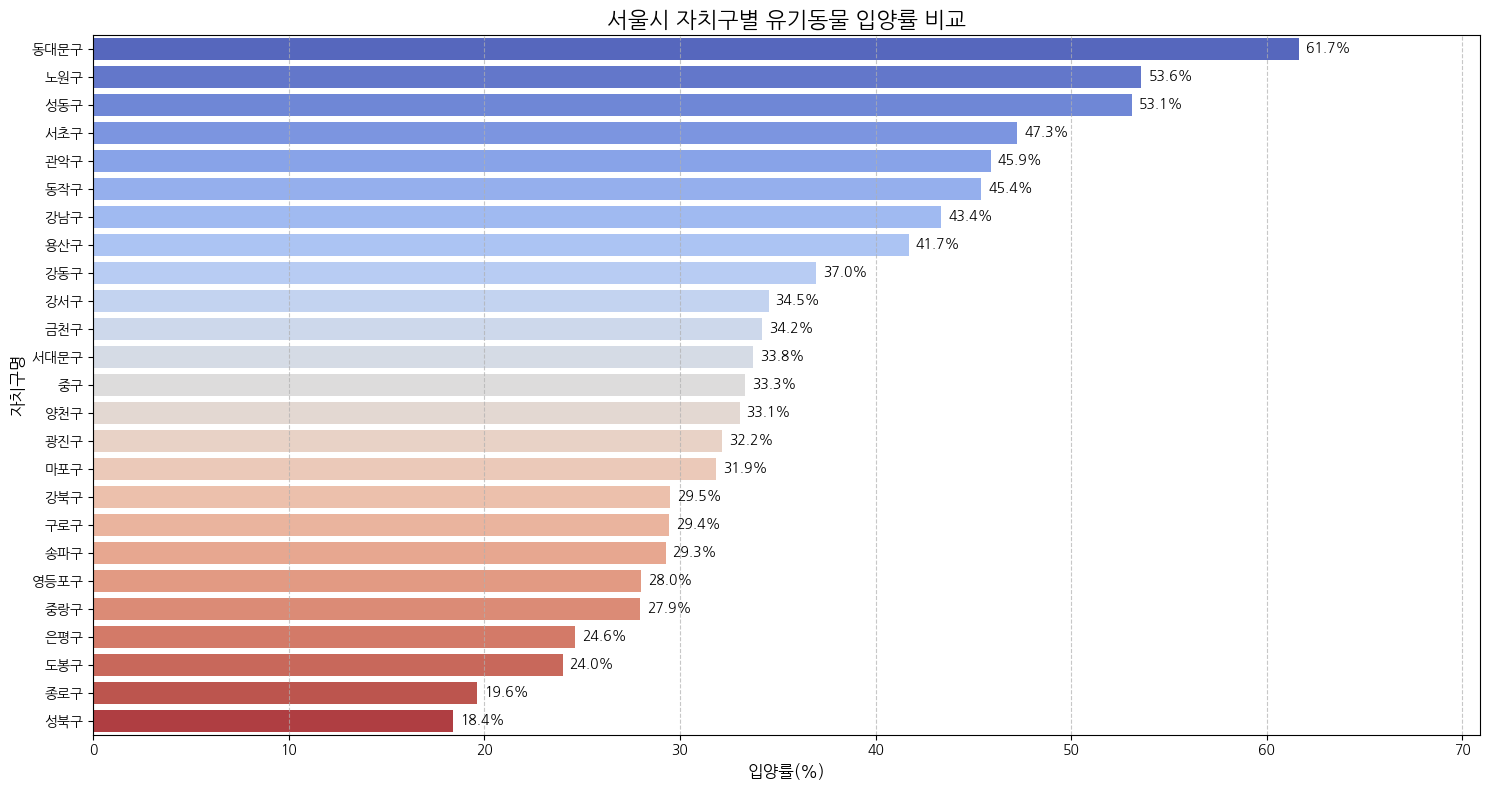

In [ ]:
!sudo apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 4. 시각화
# 그래프 크기 증가 (width, height)
plt.figure(figsize=(15, 8))

ax = sns.barplot(
    data=df_filtered.sort_values('입양률', ascending=False),
    x='입양률',
    y='자치구명',
    hue='자치구명',
    palette='coolwarm',
    legend=False
)

plt.title('서울시 자치구별 유기동물 입양률 비교', fontsize=16)
plt.xlabel('입양률(%)', fontsize=12)
plt.ylabel('자치구명', fontsize=12)

# 막대 끝에 퍼센트 표시
# x축 최대값에 여유를 주어 텍스트가 잘리지 않도록 설정
max_rate = df_filtered['입양률'].max()
plt.xlim(0, max_rate * 1.15) # 최대 입양률의 15% 정도 더 여유 공간 확보

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5) # padding 증가

plt.grid(axis='x', linestyle='--', alpha=0.7) # 그리드 추가로 가독성 향상
plt.tight_layout() # 그래프 요소들이 겹치지 않게 자동 조절
plt.show()

**자치구 간 입양률의 큰 편차 (불균형 확인)**: 가장 높은 동대문구(약 60% 이상)와 가장 낮은 성북구(약 20% 미만) 사이의 입양률 차이가 3배 이상 벌어지고 있다.

<h1 id="section-7">7. 자치구별 보호 지표 종합 비교: 4개 지표 막대그래프</h1>

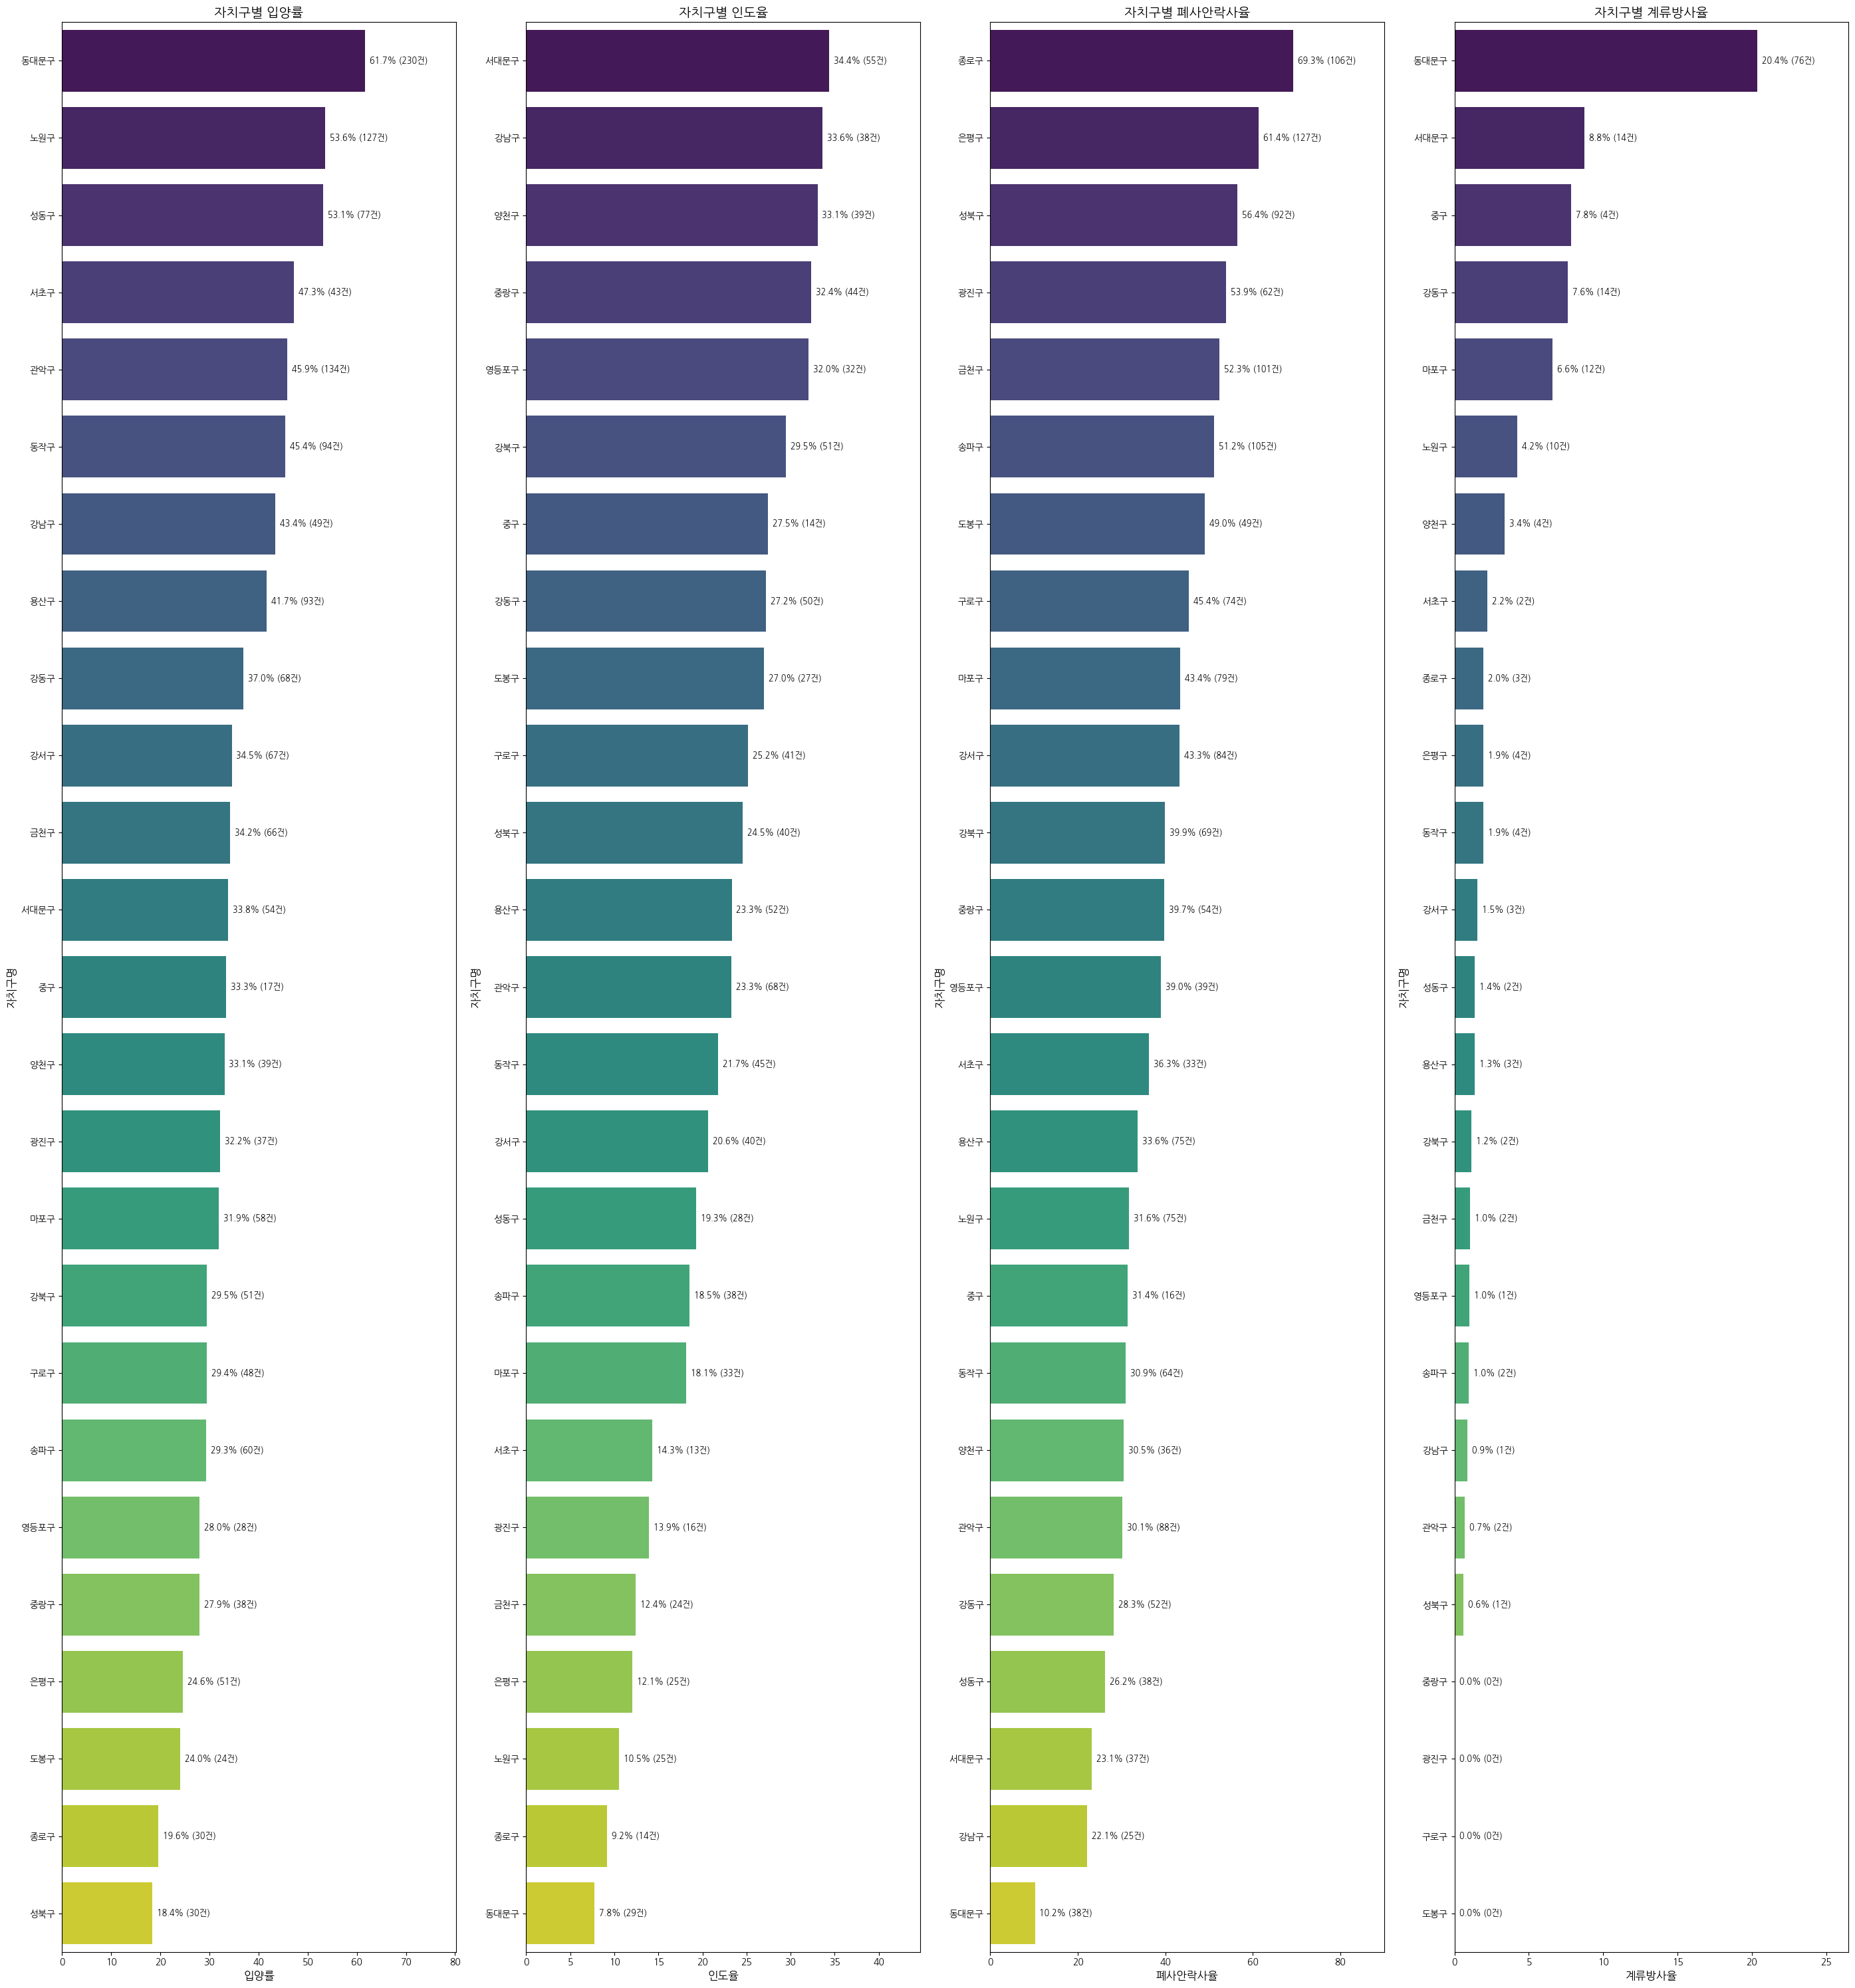

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 한글 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# '소계' 행을 제외한 데이터 필터링
df_filtered = df[df['자치구명'] != '소계'].copy() # Use .copy() to prevent SettingWithCopyWarning

# Calculate count columns for labels
df_filtered['입양건수'] = df_filtered['개_입양기증'] + df_filtered['고양이_입양기증'] + df_filtered['기타_입양기증']
df_filtered['인도건수'] = df_filtered['개_인도(주인)'] + df_filtered['고양이_인도(주인)'] + df_filtered['기타_인도(주인)']
df_filtered['폐사안락사건수'] = df_filtered['개_폐사안락사'] + df_filtered['고양이_폐사안락사'] + df_filtered['기타_폐사안락사']
df_filtered['계류방사건수'] = df_filtered['개_계류방사'] + df_filtered['고양이_계류방사'] + df_filtered['기타_계류방사']

# Mapping of metrics to their corresponding count columns
metric_to_count = {
    '입양률': '입양건수',
    '인도율': '인도건수',
    '폐사안락사율': '폐사안락사건수',
    '계류방사율': '계류방사건수'
}

# 1x4 구조로 그래프 배치. 높이를 충분히 확보하여 y축 레이블 겹침 방지
fig, axes = plt.subplots(1, 4, figsize=(28, 30)) # Increased width to 28 to accommodate longer labels

# 각 지표에 대한 리스트
metrics = ['입양률', '인도율', '폐사안락사율', '계류방사율']

for i, metric in enumerate(metrics):
    # Sort data for the current metric
    sorted_df = df_filtered.sort_values(metric, ascending=False).reset_index(drop=True) # Reset index for easier access

    ax = sns.barplot(data=sorted_df,
                x=metric, y='자치구명', hue='자치구명', ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(f'자치구별 {metric}', fontsize=14)
    axes[i].set_xlabel(metric, fontsize=12)
    axes[i].set_ylabel('자치구명', fontsize=12)
    axes[i].tick_params(axis='y', labelsize=10)

    # Get the corresponding count column name
    count_col = metric_to_count[metric]

    # Add percentage and count labels to the bars
    for j, p in enumerate(ax.patches):
        percentage = sorted_df[metric].iloc[j]
        count = sorted_df[count_col].iloc[j]
        ax.annotate(f'{percentage:.1f}% ({int(count)}건)',
                    (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=9, color='black', xytext=(5, 0),
                    textcoords='offset points')

    # Adjust x-axis limit to give space for labels
    max_val = sorted_df[metric].max()
    ax.set_xlim(0, max_val * 1.3) # Increased padding for potentially longer labels

plt.tight_layout() # 그래프 요소들이 겹치지 않게 자동 조절
plt.show()

1. **입양률 (Adoption Rate)**: 동대문구, 노원구 등은 50% 이상의 높은 입양률을 기록 중이나, 성북구, 종로구 등은 20% 미만으로 나타난다. 최대 3배 이상의 격차는 자치구별 입양 홍보 인프라 및 유기동물 인식 개선 사업의 차이에서 기인한 것으로 보인다.

2. **인도율 (Reclaim Rate)**: 서대문구, 강남구 등이 높은 인도율을 보이는 반면, 동대문구는 상대적으로 낮다. 인도율은 반려동물 등록제 정착 여부와 밀접한 관련이 있는 것으로 판단된다.

3. **폐사·안락사율 (Euthanasia/Death Rate)**: 종로구, 은평구, 성북구 등이 높은 비율을 보인다. 이는 입양률이 낮은 자치구와 상당 부분 겹치며, 보호소의 수용 한계 및 치료 인프라 부족이 안락사율 상승으로 이어졌을 가능성이 높다.

4. **계류·방사율 (Feral/Stray Management)**: 동대문구가 압도적으로 높은 수치를 보인다. 이는 길고양이 TNR(중성화 사업) 등 방사 중심의 관리 체계가 해당 구에서 집중적으로 운영되고 있음을 시사한다.

<h1 id="section-8">8. 자치구별 보호 지표 히트맵 분석</h1>

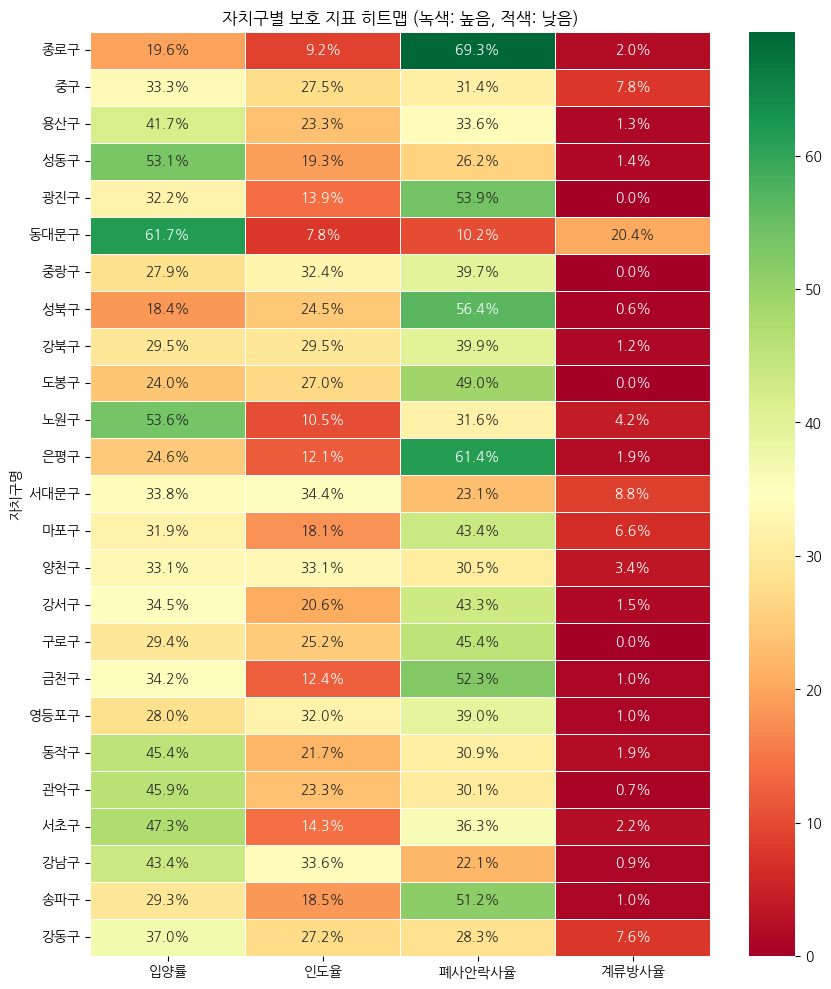

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화할 데이터만 추출 (자치구명은 인덱스로 사용)
heatmap_data = df_filtered.set_index('자치구명')[['입양률', '인도율', '폐사안락사율', '계류방사율']]

# 2. 어노테이션에 사용할 문자열 데이터프레임 생성 (소수점 첫째 자리까지 표시하고 '%' 추가)
annot_labels = heatmap_data.map(lambda x: f'{x:.1f}%') # Changed applymap to map

# 3. 히트맵 그리기
plt.figure(figsize=(10, 12))
sns.heatmap(heatmap_data, annot=annot_labels, cmap='RdYlGn', fmt="", linewidths=.5) # annot에 문자열 DataFrame 전달, fmt=""로 설정
plt.title('자치구별 보호 지표 히트맵 (녹색: 높음, 적색: 낮음)')
plt.show()

1. **입양률 (Adoption Rate)**: 동대문구(61.7%)가 가장 높은 수치를 보이며, 성북구(18.4%)가 가장 낮은 수준을 기록한다.또한 자치구별로 입양 성과에 대한 편차가 상당히 크게 나타나고 있다.


2. **인도율 (Reclaim Rate)**: 서대문구(34.4%)와 강남구(33.6%)가 비교적 높은 인도율을 나타내는 반면, 동대문구(7.8%)는 낮은 인도율을 보인다.


3. **폐사 및 안락사율 (Euthanasia/Death Rate)**: 종로구(69.3%)가 가장 높은 비율을 차지하고 있으며, 은평구(61.4%)와 성북구(56.4%) 또한 높은 수준이다.대체로 입양률이 낮은 자치구에서 폐사·안락사율이 높게 나타나는 음의 상관관계를 보인다.


4. **계류 및 방사율 (Feral/Stray Management)**: 동대문구(20.4%)가 다른 자치구에 비해 압도적으로 높은 수치를 기록하고 있다.

<h1 id="section-9">9. 입양률과 폐사·안락사율의 관계 분석</h1>

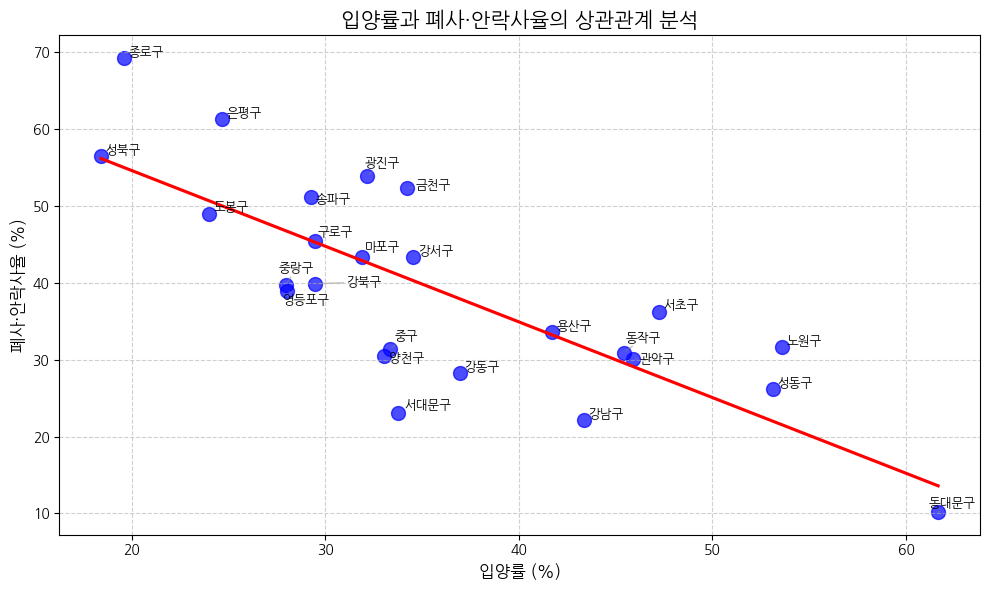

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text # Import adjust_text

# 1. 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 2. 산점도 그리기
# x축: 입양률, y축: 폐사안락사율
sns.regplot(data=df_filtered, x='입양률', y='폐사안락사율',
            scatter_kws={'s': 100, 'color': 'blue', 'alpha': 0.7},
            line_kws={'color': 'red'}, ci=None) # Use regplot for scatter and trendline, ci=None for no confidence interval

# 3. 자치구 이름 표시 (adjust_text를 사용하기 위해 텍스트 객체들을 리스트에 저장)
texts = []
for i in range(df_filtered.shape[0]):
    # Removed manual offset, adjust_text will handle positioning
    t = plt.text(df_filtered['입양률'].iloc[i], df_filtered['폐사안락사율'].iloc[i], df_filtered['자치구명'].iloc[i], fontsize=9)
    texts.append(t)

# 4. adjust_text를 사용하여 텍스트 겹침 방지
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

plt.title('입양률과 폐사·안락사율의 상관관계 분석', fontsize=15)
plt.xlabel('입양률 (%)', fontsize=12)
plt.ylabel('폐사·안락사율 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

1.   본 산점도에 삽입된 빨간색 추세선은 입양률과 폐사·안락사율 간의 음(-)의 상관관계를 통계적으로 도출한 회귀선이다. 입양률이 개선될수록 폐사·안락사율이 유의미하게 감소함을 보여주며, 이는 입양 활성화가 유기동물 생존율을 높이는 핵심 동인임을 데이터로 입증한다.

2.   이상치 진단: 동대문구는 입양률은 높고 안락사율은 낮은 '이상적 모델'로 관찰되는 반면, 종로구 등 일부 자치구는 추세선 대비 높은 안락사율을 보여 즉각적인 개입이 필요하다.

<h1 id="section-10">10. 보호 지표 분포 및 이상치 분석: 박스플롯</h1>

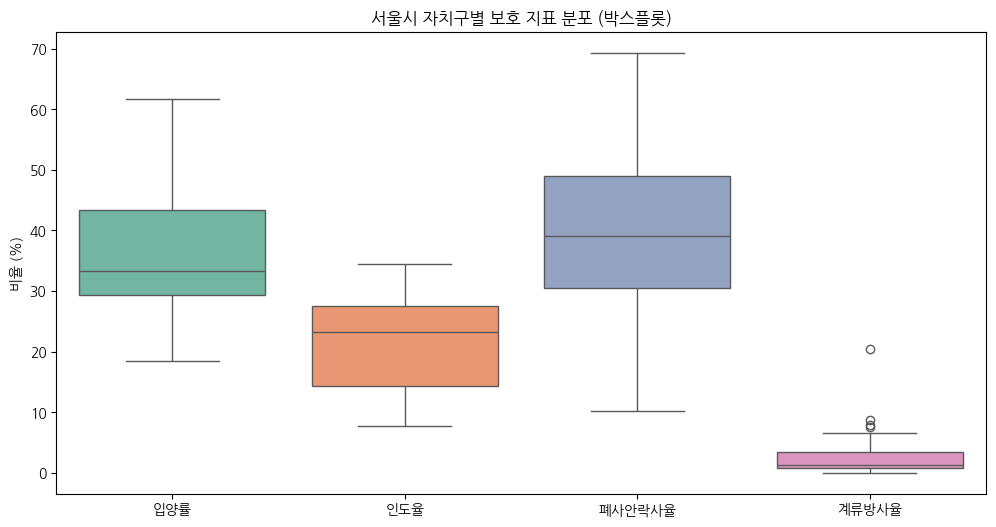

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 구조에 맞게 리스트로 변환
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered[['입양률', '인도율', '폐사안락사율', '계류방사율']], palette="Set2")

plt.title('서울시 자치구별 보호 지표 분포 (박스플롯)')
plt.ylabel('비율 (%)')
plt.show()

1.   **지표별 중심 경향**: '입양률'은 중앙값이 약 30%대 초반에 형성되어 있으나, '폐사안락사율'의 중앙값은 40%에 육박한다. 이는 서울시 유기동물 보호소의 현실적인 운영 현황이 입양보다는 안락사/폐사 비중이 더 높게 나타나고 있음을 보여준다.

2.   **편차(격차)의 크기**: '폐사안락사율'의 박스 크기가 다른 지표에 비해 크고 수염도 길게 뻗어 있다. 이는 자치구별로 안락사 관리 수준의 차이가 매우 크다는 것을 의미한다.

3.  **이상치(Outlier)의 의미**: '계류방사율'에서 발견되는 동그라미들은 특정 자치구가 타 지역에 비해 압도적으로 높은 계류·방사율을 보인다는 뜻이다(앞선 막대 그래프에서 본 '동대문구' 같은 사례). 이는 해당 지역의 독특한 동물 복지 정책이 반영된 결과로 해석할 수 있다.

<h1 id="section-11">11. 자치구별 인구 데이터 불러오기</h1>

In [ ]:
# 1. 인구 데이터 불러오기
df_pop = pd.read_csv('/content/자치구별+총인구(추계인구)_20260617012038.csv', header=[0, 1])
df_pop

자치구별(1)  자치구별(2)     2022                       2023                    \
    자치구별(1)  자치구별(2)      총인구    총인구.1    총인구.2      총인구    총인구.1    총인구.2   
0   자치구별(1)  자치구별(2)       소계       남자       여자       소계       남자       여자   
1        합계       소계  9421415  4552192  4869223  9400365  4535176  4865189   
2        합계      종로구   146891    70211    76680   146684    70004    76680   
3        합계       중구   124819    59661    65158   126473    60422    66051   
4        합계      용산구   218951   105360   113591   217722   104851   112871   
5        합계      성동구   282740   137109   145631   280423   135843   144580   
6        합계      광진구   346409   165964   180445   345623   165396   180227   
7        합계     동대문구   347808   168634   179174   352596   170494   182102   
8        합계      중랑구   380540   186174   194366   377639   184187   193452   
9        합계      성북구   435613   207386   228227   434788   206485   228303   
10       합계      강북구   288916   139127   149789   284998   136977   148021   
11       합계      도봉구   305642   147379   158263   300976   144935   156041   
12       합계      노원구   498182   239025   259157   492070   235844   256226   
13       합계      은평구   457398   217769   239629   449355   213088   236267   
14       합계     서대문구   316135   146216   169919   322097   148719   173378   
15       합계      마포구   362971   169250   193721   363474   168936   194538   
16       합계      양천구   428903   209612   219291   423982   206797   217185   
17       합계      강서구   557793   267025   290768   553209   264442   288767   
18       합계      구로구   422716   210171   212545   425209   211160   214049   
19       합계      금천구   247305   125286   122019   246497   124749   121748   
20       합계     영등포구   399946   198191   201755   402668   199048   203620   
21       합계      동작구   387889   187135   200754   385189   186000   199189   
22       합계      관악구   494347   246929   247418   497498   248796   248702   
23       합계      서초구   383939   183375   200564   383128   182599   200529   
24       합계      강남구   499817   239180   260637   508057   243024   265033   
25       합계      송파구   637016   306660   330356   632393   303919   328474   
26       합계      강동구   448729   219363   229366   447617   218461   229156   

       2024           ...     2039     2040                       2041  \
        총인구    총인구.1  ...    총인구.2      총인구    총인구.1    총인구.2      총인구   
0        소계       남자  ...       여자       소계       남자       여자       소계   
1   9393699  4520521  ...  4598212  8709899  4133113  4576786  8662766   
2    146227    69513  ...    69136   129636    60852    68784   128900   
3    127022    60383  ...    63419   118702    55562    63140   118067   
4    207409    99417  ...    99241   187845    89142    98703   186705   
5    278757   134470  ...   129642   244140   115389   128751   242212   
6    345068   164548  ...   163930   306484   143515   162969   304393   
7    357112   172299  ...   174684   331885   158207   173678   329711   
8    376147   182783  ...   183623   349986   167119   182867   348181   
9    431377   204440  ...   210296   391877   182726   209151   389418   
10   280273   134192  ...   128535   242556   114896   127660   240829   
11   298678   143391  ...   138676   261597   123787   137810   259807   
12   489087   233941  ...   229915   429530   201005   228525   426558   
13   453735   214452  ...   234090   433290   199968   233322   431464   
14   319148   147081  ...   159778   294134   134991   159143   292705   
15   363402   168242  ...   184136   336732   153499   183233   334809   
16   421425   205042  ...   203069   387214   184908   202306   385440   
17   548230   261730  ...   266168   501002   236134   264868   498136   
18   421170   208682  ...   199138   387062   188710   198352   385205   
19   244446   123493  ...   111525   221814   110821   110993   220585   
20   402439   197979  ...   196735   379468   183546   195922   377504   
21   384310   185357  ...   181436   34

<h2 id="section-11-1">11-1. 인구 데이터 전처리</h2>

In [ ]:
# 필요한 데이터만 선택하고 정리
# '자치구명' 컬럼은 MultiIndex에서 ('자치구별(2)', '자치구별(2)')
# '2025년 총인구' 컬럼은 MultiIndex에서 ('2025', '총인구')

# 실제 데이터는 MultiIndex 헤더 다음의 두 행을 건너뛰고 시작합니다.
df_pop_clean = df_pop.iloc[2:].copy() # Skip first two rows which are headers/summaries

# MultiIndex 컬럼에서 원하는 컬럼을 정확히 선택 (튜플로 접근)
df_pop_clean = df_pop_clean[[('자치구별(2)', '자치구별(2)'), ('2025', '총인구')]]

# 컬럼 이름 변경 (단순화)
df_pop_clean.columns = ['자치구명', '2025_총인구']

# '자치구명' 컬럼의 공백 제거 (trim whitespace) 및 타입 변환
df_pop_clean['자치구명'] = df_pop_clean['자치구명'].str.strip()

# 서울시 자치구만 대상으로 하므로 '합계' 또는 '소계'와 같은 집계 행만 제거합니다.
# '종로구'를 포함한 모든 자치구가 유지됩니다.
# (df_pop.iloc[2:]를 사용했으므로 이 시점에서 '소계'는 '자치구명' 컬럼에 없을 가능성이 높지만, 안전을 위해 유지)
df_pop_clean = df_pop_clean[df_pop_clean['자치구명'] != '소계'].reset_index(drop=True)

# 인구수 컬럼을 숫자로 변환 (콤마 제거 및 타입 변경)
df_pop_clean['2025_총인구'] = df_pop_clean['2025_총인구'].astype(str).str.replace(',', '').astype(float)

# 정제된 df_pop_clean 데이터 확인
df_pop_clean.info()
display(df_pop_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   자치구명      25 non-null     object 
 1   2025_총인구  25 non-null     float64
dtypes: float64(1), object(1)
memory usage: 532.0+ bytes


,자치구명,2025_총인구
0,종로구,144162.0
1,중구,126858.0
2,용산구,203513.0
3,성동구,274980.0
4,광진구,341787.0
5,동대문구,357700.0
6,중랑구,373463.0
7,성북구,426571.0
8,강북구,275424.0
9,도봉구,295276.0


In [ ]:
# 두 데이터프레임의 자치구명 리스트를 뽑아서 비교
# df_filtered는 '소계' 행이 제외된 유기동물 데이터입니다.
set_animal = set(df_filtered['자치구명'])
set_pop = set(df_pop_clean['자치구명'])

# 1. df_filtered에는 있지만 df_pop_clean에는 없는 자치구 확인
print("df_filtered에는 있지만 df_pop_clean에 없는 것:", set_animal - set_pop)

# 2. df_pop_clean에는 있지만 df_filtered에 없는 자치구 확인
print("df_pop_clean에는 있지만 df_filtered에 없는 것:", set_pop - set_animal)

# 결과가 모두 비어있다면(set()) 아주 완벽하게 일치하는 것입니다!

df_filtered에는 있지만 df_pop_clean에 없는 것: set()
df_pop_clean에는 있지만 df_filtered에 없는 것: set()


<h1 id="section-12">12. 유기동물 데이터와 인구 데이터 병합</h1>

In [ ]:
# '자치구명' 컬럼을 기준으로 inner join을 수행합니다.
# 이렇게 하면 두 데이터셋에 공통으로 존재하는 자치구의 데이터만 남게 됩니다.
df_merged = pd.merge(df_filtered, df_pop_clean, on='자치구명', how='inner')

# 2. 병합된 데이터프레임 확인
display(df_merged.head())
df_merged.info()

,구분,자치구명,총_합계,개_소계,개_인도(주인),개_입양기증,개_폐사안락사,개_계류방사,고양이_소계,고양이_인도(주인),...,기타_계류방사,입양률,인도율,폐사안락사율,계류방사율,입양건수,인도건수,폐사안락사건수,계류방사건수,2025_총인구
0,합계,종로구,153,48,13,11,24,0,101,1,...,0,19.607843,9.150327,69.281046,1.960784,30,14,106,3,144162.0
1,합계,중구,51,23,11,7,5,0,20,2,...,2,33.333333,27.450980,31.372549,7.843137,17,14,16,4,126858.0
2,합계,용산구,223,78,50,17,11,0,135,2,...,0,41.704036,23.318386,33.632287,1.345291,93,52,75,3,203513.0
3,합계,성동구,145,45,23,16,6,0,88,5,...,0,53.103448,19.310345,26.206897,1.379310,77,28,38,2,274980.0
4,합계,광진구,115,46,16,21,9,0,68,0,...,0,32.173913,13.913043,53.913043,0.000000,37,16,62,0,341787.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   구분          25 non-null     object 
 1   자치구명        25 non-null     object 
 2   총_합계        25 non-null     int64  
 3   개_소계        25 non-null     int64  
 4   개_인도(주인)    25 non-null     int64  
 5   개_입양기증      25 non-null     int64  
 6   개_폐사안락사     25 non-null     int64  
 7   개_계류방사      25 non-null     int64  
 8   고양이_소계      25 non-null     int64  
 9   고양이_인도(주인)  25 non-null     int64  
 10  고양이_입양기증    25 non-null     int64  
 11  고양이_폐사안락사   25 non-null     int64  
 12  고양이_계류방사    25 non-null     int64  
 13  기타_소계       25 non-null     int64  
 14  기타_인도(주인)   25 non-null     int64  
 15  기타_입양기증     25 non-null     int64  
 16  기타_폐사안락사    25 non-null     int64  
 17  기타_계류방사     25 non-null     int64  
 18  입양률         25 non-null     float64
 19  인도율         25 non-null     flo

<h1 id="section-13">13. 인구 표준화 지표 계산: 인구 1만명당 발생률 계산</h1>

In [ ]:
# 인구수 대비 유기동물 발생률 계산
df_merged['인구_만명당_총_발생률'] = (df_merged['총_합계'] / df_merged['2025_총인구']) * 10000

# 계산된 새로운 지표 확인
display(df_merged[['자치구명', '총_합계', '2025_총인구', '인구_만명당_총_발생률']])

,자치구명,총_합계,2025_총인구,인구_만명당_총_발생률
0,종로구,153,144162.0,10.613060
1,중구,51,126858.0,4.020243
2,용산구,223,203513.0,10.957531
3,성동구,145,274980.0,5.273111
4,광진구,115,341787.0,3.364669
5,동대문구,373,357700.0,10.427733
6,중랑구,136,373463.0,3.641592
7,성북구,163,426571.0,3.821169
8,강북구,173,275424.0,6.281225
9,도봉구,100,295276.0,3.386662


In [ ]:
# 병합 전 데이터의 행 개수 확인
print("병합 전 행 개수:", len(df_filtered))

# 병합 후 데이터의 행 개수 확인
print("병합 후 행 개수:", len(df_merged))

병합 전 행 개수: 25
병합 후 행 개수: 25


<h1 id="section-14">14. 최종 분석 데이터 저장</h1>

In [ ]:
# df_merged를 'df_final'이라는 이름으로 새로 저장
df_final = df_merged.copy()

In [ ]:
# 기존에 저장했던 파일이 있어도, 이 코드를 실행하면 새로운 파일명이 생성됩니다.
df_merged.to_csv('서울시_유기동물_최종분석_2026.csv', index=False, encoding='utf-8-sig')

print("새로운 이름으로 저장되었습니다!")

새로운 이름으로 저장되었습니다!


In [ ]:
from google.colab import files
# 파일을 다시 저장하고 다운로드를 시도합니다.
df_merged.to_csv('서울시_유기동물_최종분석_2026.csv', index=False, encoding='utf-8-sig')

print("파일이 다시 저장되었습니다. 이제 다운로드를 시도합니다.")
files.download('서울시_유기동물_최종분석_2026.csv')

파일이 다시 저장되었습니다. 이제 다운로드를 시도합니다.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<h1 id="section-15">15. 인구 1만명당 유기동물 발생률 비교: 막대그래프</h1>

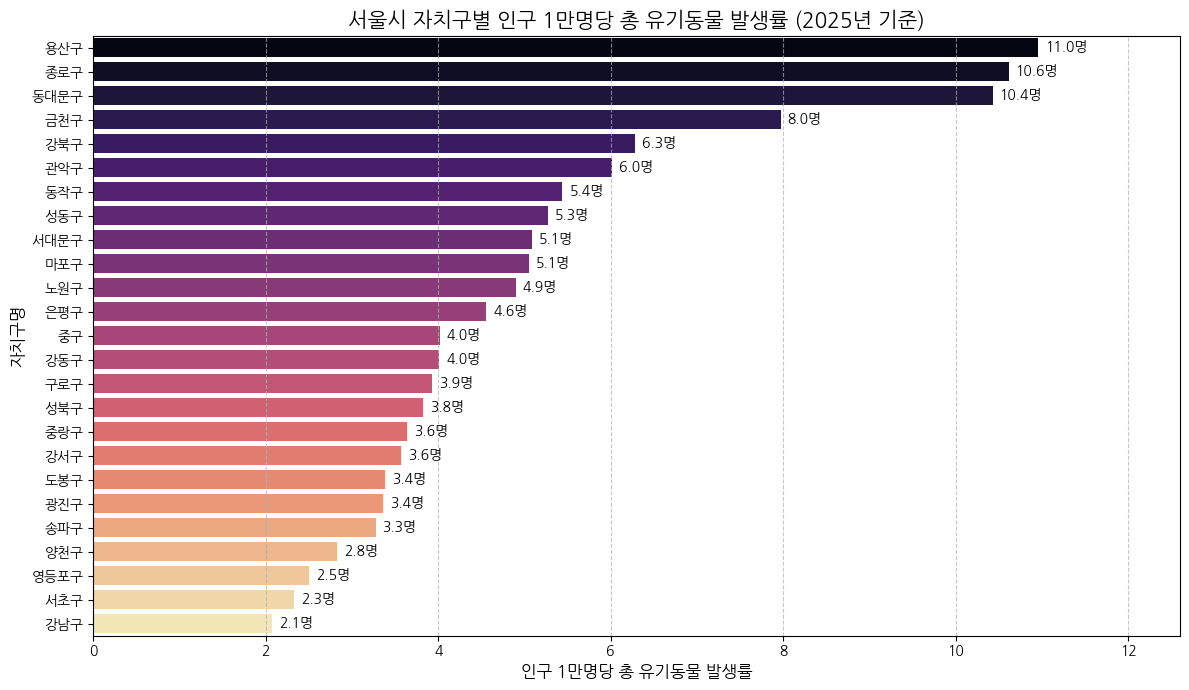

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 그래프 크기 설정
plt.figure(figsize=(12, 7))

# 2. 막대 그래프 그리기 (내림차순 정렬)
ax = sns.barplot(data=df_merged.sort_values('인구_만명당_총_발생률', ascending=False),
                 x='인구_만명당_총_발생률',
                 y='자치구명',
                 hue='자치구명',
                 palette='magma',
                 legend=False)

# 3. 제목 및 레이블 설정
plt.title('서울시 자치구별 인구 1만명당 총 유기동물 발생률 (2025년 기준)', fontsize=15)
plt.xlabel('인구 1만명당 총 유기동물 발생률', fontsize=12)
plt.ylabel('자치구명', fontsize=12)

# 4. 격자선 설정
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 5. 오른쪽 여백 확보 (글자가 잘리지 않게)
plt.xlim(0, df_merged['인구_만명당_총_발생률'].max() * 1.15)

# 6. 막대 끝에 수치(명) 표시
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}명',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                va='center', ha='left', fontsize=10, color='black', xytext=(5, 0), textcoords='offset points')

plt.tight_layout() # 그래프 요소들이 겹치지 않게 자동 조절
plt.show()

1. 용산구, 종로구, 동대문구는 다른 구들에 비해 인구 대비 유기동물 발생 비율이 매우 높다.

2.  반면 강남구, 서초구, 영등포구는 인구가 많음에도 불구하고 인구 대비 발생률은 매우 낮다.




<h1 id="section-16">16. 인구수와 유기동물 발생 건수의 관계 분석: 인구수 vs 총 발생 건수 산점도</h1>

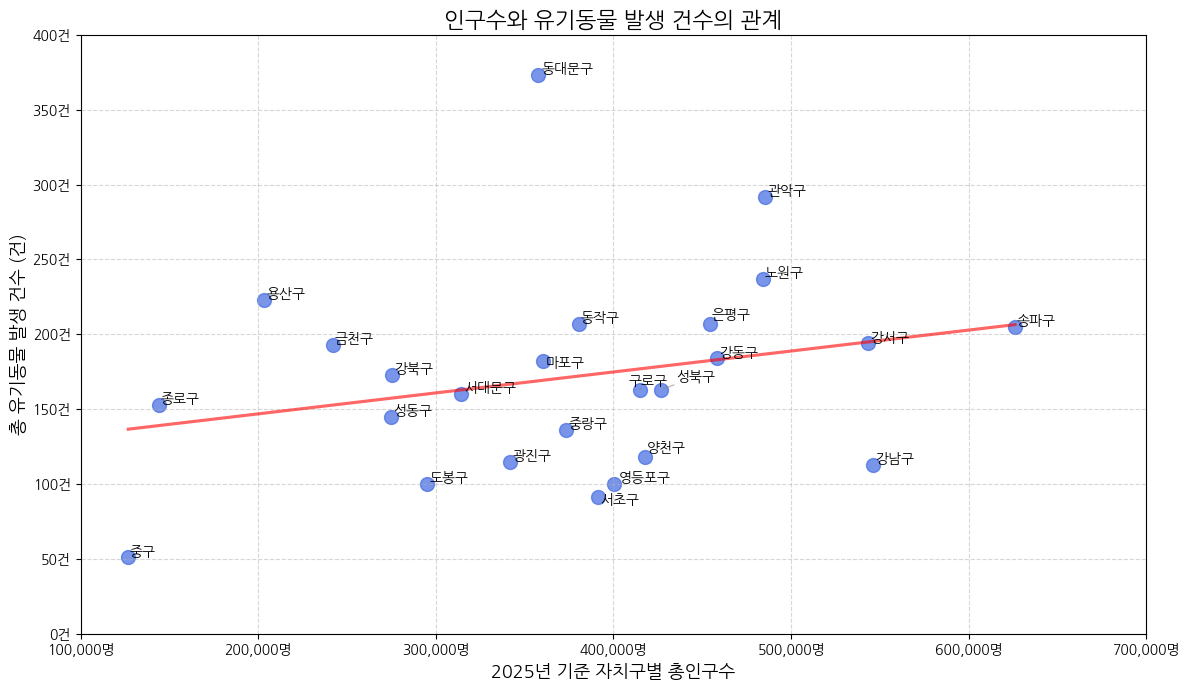

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

# 1. 그래프 설정
plt.figure(figsize=(12, 7))

# 2. 산점도 + 추세선(regplot 사용)
sns.regplot(data=df_merged, x='2025_총인구', y='총_합계',
            scatter_kws={'s': 100, 'color': 'royalblue', 'alpha': 0.7},
            line_kws={'color': 'red', 'alpha': 0.6}, ci=None)

# 3. 각 점마다 구 이름 표시 (adjust_text를 사용하기 위해 텍스트 객체들을 리스트에 저장)
texts = []
for i in range(len(df_merged)):
    t = plt.text(df_merged['2025_총인구'][i], df_merged['총_합계'][i], df_merged['자치구명'][i],
             fontsize=10)
    texts.append(t)

# 4. 글자 겹침 방지
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

# 5. 제목 및 레이블 (단위 추가)
plt.title('인구수와 유기동물 발생 건수의 관계', fontsize=16)
plt.xlabel('2025년 기준 자치구별 총인구수', fontsize=13)
plt.ylabel('총 유기동물 발생 건수 (건)', fontsize=13)

# 6. Y축 눈금에 '건' 붙이기 (UserWarning 방지)
current_yticks_locs = plt.gca().get_yticks()
plt.gca().set_yticks(current_yticks_locs)
plt.gca().set_yticklabels([f'{int(y)}건' for y in current_yticks_locs])

# 7. X축 눈금에 쉼표(,)와 '명' 붙이기 (UserWarning 방지)
current_xticks_locs = plt.gca().get_xticks()
plt.gca().set_xticks(current_xticks_locs)
plt.gca().set_xticklabels([f'{int(x):,}명' for x in current_xticks_locs])

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

1. 동대문구의 특이성 (Outlier 발견)
해석: 그래프 상단을 보면 동대문구가 독보적으로 위에 있다. 인구는 중간 정도인데 발생 건수는 가장 높다. 이는 동대문구에만 유독 유기동물이 많이 생길 수밖에 없는 환경적 요인(예: 대형 보호소 위치, 특정 지역 특성, 혹은 등록률 관련 이슈 등)이 존재한다는 강력한 가설을 제시한다. 가장 먼저 조사를 해봐야 할 지역이라는 의미다.

2. 인구와 발생 건수의 낮은 상관관계
해석: 만약 인구와 발생 건수가 비례한다면 점들이 오른쪽 위로 대각선을 그리며 모여 있어야 한다. 하지만 점들이 전체적으로 흩어져 있는데 이는 "인구가 많다고 해서 유기동물이 많이 발생하는 것은 아니다"라는 사실을 입증한다. 즉, 유기동물 문제는 인구수 같은 외형적 조건보다 지역사회의 관리 수준, 동물 보호 문화, 정책적 노력이 더 중요하다는 결론으로 이어진다.

3. 상반된 사례 비교 (강남구 vs 동대문구)
해석: X축(인구수)을 보면 강남구는 오른쪽에(인구가 많음), 동대문구는 중간에 있다. 그런데 Y축(발생 건수)을 보면 동대문구가 훨씬 높다. 이렇게 두 구를 대비시키면, 단순히 인구가 많은 곳을 관리하는 것이 아니라 "발생률이 높은 곳을 우선적으로 지원해야 한다"는 정책적 당위성을 아주 설득력 있게 설명할 수 있다.

<h1 id="section-17">17. 주요 위험 지역 도출: 유기동물 발생률 상위/하위 지역 확인</h1>

In [ ]:
print('\n[인구 1만명당 총 유기동물 발생률 상위 5개구]')
display(df_merged.sort_values(by='인구_만명당_총_발생률', ascending=False)[['자치구명', '인구_만명당_총_발생률']].head(5))

print('\n[인구 1만명당 총 유기동물 발생률 하위 5개구]')
display(df_merged.sort_values(by='인구_만명당_총_발생률', ascending=True)[['자치구명', '인구_만명당_총_발생률']].head(5))


[인구 1만명당 총 유기동물 발생률 상위 5개구]


,자치구명,인구_만명당_총_발생률
2,용산구,10.957531
0,종로구,10.613060
5,동대문구,10.427733
17,금천구,7.969641
8,강북구,6.281225



[인구 1만명당 총 유기동물 발생률 하위 5개구]


,자치구명,인구_만명당_총_발생률
22,강남구,2.068476
21,서초구,2.324162
18,영등포구,2.498364
14,양천구,2.824872
23,송파구,3.274112


<h2 id="section-17-1">17-1. 주요 위험 지역 도출: 폐사·안락사율 상위/하위 지역 확인</h2>

In [ ]:

print("\n[인구 1만명당 총 폐사·안락사율 상위 5개구]")
display(df_merged.sort_values(by='폐사안락사율', ascending=False)[['자치구명', '폐사안락사율']].head(5))

print("\n[인구 1만명당 총 폐사·안락사율 하위 5개구]")
display(df_merged.sort_values(by='폐사안락사율', ascending=True)[['자치구명', '인구_만명당_총_발생률']].head(5))



[인구 1만명당 총 폐사·안락사율 상위 5개구]


,자치구명,폐사안락사율
0,종로구,69.281046
11,은평구,61.352657
7,성북구,56.441718
4,광진구,53.913043
17,금천구,52.331606



[인구 1만명당 총 폐사·안락사율 하위 5개구]


,자치구명,인구_만명당_총_발생률
5,동대문구,10.427733
22,강남구,2.068476
12,서대문구,5.088346
3,성동구,5.273111
24,강동구,4.012377


<h1 id="section-18">18. 입양률과 폐사·안락사율의 상관관계 분석: 산점도</h1>

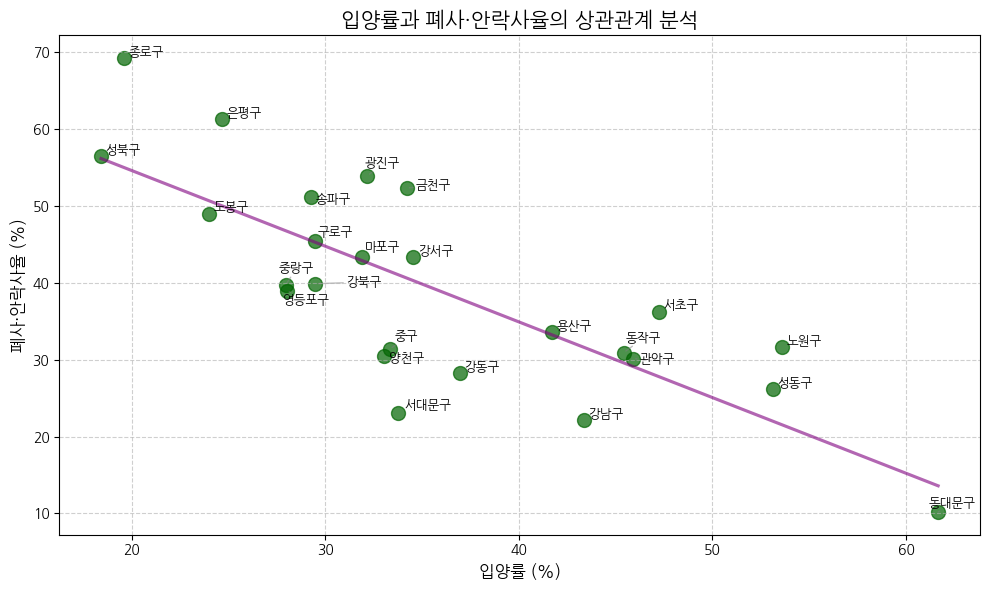

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text # Import adjust_text

# 1. 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 2. 산점도 그리기
# x축: 입양률, y축: 폐사안락사율
sns.regplot(data=df_merged, x='입양률', y='폐사안락사율',
            scatter_kws={'s': 100, 'color': 'darkgreen', 'alpha': 0.7},
            line_kws={'color': 'purple', 'alpha': 0.6}, ci=None)

# 3. 자치구 이름 표시 (adjust_text를 사용하기 위해 텍스트 객체들을 리스트에 저장)
texts = []
for i in range(df_merged.shape[0]):
    t = plt.text(df_merged['입양률'].iloc[i], df_merged['폐사안락사율'].iloc[i], df_merged['자치구명'].iloc[i], fontsize=9)
    texts.append(t)

# 4. adjust_text를 사용하여 텍스트 겹침 방지
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

# 5. 제목 및 레이블
plt.title('입양률과 폐사·안락사율의 상관관계 분석', fontsize=15)
plt.xlabel('입양률 (%)', fontsize=12)
plt.ylabel('폐사·안락사율 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # 그래프 요소들이 겹치지 않게 자동 조절
plt.show()

입양률과 폐사·안락사율의 관계를 산점도로 확인한 결과, 추세선이 하락하는 형태를 보였다. 이는 입양률이 높은 자치구일수록 폐사·안락사율이 낮아지는 경향이 있음을 의미한다. 따라서 입양 활성화는 유기동물 보호 성과를 개선하는 데 중요한 요인일 수 있다. 다만 이 그래프는 상관관계를 보여주는 것이므로, 직접적인 원인으로 해석하기 위해서는 추가 분석이 필요하다.